# Elder's Triple Screen — a quantitative teardown 🔬
### Mechanical 3-screen longs on 5 indices · weekly-trend + daily-pullback + breakout · forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a screen-scramble alignment placebo · costs · a synthetic planted-bounce control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Filter_adds_edge%3F: Busted](https://img.shields.io/badge/Filter_adds_edge%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **system** from the **drift**: an upward-trending index makes *any* trend-following dip-buy look good, so the only meaningful test is triple-vs-random, plus a placebo that destroys the timeframe alignment while preserving each screen's marginal.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Screen 1 (weekly MACD-hist slope) is shifted **one day** (no look-ahead); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from elder_triple_screen import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real triple-screen cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 2369, 'fp_spy': '4cb5244f3990', 'h5': (5, 2368, 10.9, 55, 2.1, 24.9, -14.0, 8.9, -1.92, 0.054), 'h10': (10, 2363, 31.9, 60, 3.77, 29.7, 2.3, 29.9, 0.22, 0.823), 'h20': (20, 2352, 74.9, 61, 5.21, 68.5, 6.4, 72.9, 0.44, 0.657), 'h60': (60, 2344, 220.1, 67, 5.97, 257.3, -37.1, 218.1, -1.54, 0.123), 'per': [('SPY', 477, 69.0, 2.75, 69.7, -0.7), ('QQQ', 464, 113.1, 3.6, 93.8, 19.3), ('IWM', 473, 64.4, 1.84, 15.1, 49.3), ('DIA', 438, 43.9, 1.44, 57.4, -13.5), ('GLD', 517, 81.8, 2.26, 103.1, -21.3)], 'placebo': (69.0, 0.649, 500), 'syn': [(0.0, 296, -2.9, 50, -0.07), (0.5, 275, 543.3, 77, 8.29)]}


real triple-screen cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Triple-screen vs a **drift-matched random** baseline: the gap is tiny (Δ = -14/+2/+6/-37 bps at 5/10/20/60d) and the difference **never clears t = 2** (Welch t at 20d = +0.44; at 5d it is -1.92 — the filter is *worse* than a dart). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 5.21) are **pure beta** — they vanish against random entries. No residual edge to scale. |
| **Filter adds edge?** | `BUSTED` | Shifting the weekly trend out of alignment (screen-scramble placebo) leaves the result intact: **p = 0.65** of misaligned filters match or beat the real one. The alignment isn't load-bearing. |

> 💡 In plain words: the triple-screen *looks* significant only because indices drift up. Strip the drift (race it vs random) or strip the alignment (shift the trend) and the edge evaporates. Three filters, one beta-in-a-costume.

## 1 · The claim, steelmanned

Let $W_t$ be the weekly MACD-histogram slope (shifted: $W_t>0$ means last week's histogram rose), $F_t$ the daily Force-Index proxy, and $H_{t-1}$ the prior bar's high. The triple-screen long fires when **Screen 1** $W_t>0$, **Screen 2** $F_\tau<0$ for some $\tau\in[t-5,t-1]$ (a recent pullback), and **Screen 3** $C_t>H_{t-1}$ (the breakout). Enter at $C_{t+1}$.

- **H₀ (drift).** Triple-screen returns equal a drift-matched **random-entry** baseline.
- **H₁ (the system forecasts).** Triple-screen returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the alignment matters).** Triple-screen returns exceed a **screen-scramble** filter whose weekly trend is shifted out of alignment.

We find **H₀ not rejected** (Δ within a few bps), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.65). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long-only entry rule inherits it; a high one-sample $t$ against **zero** measures the tide, not the system. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of triple-*minus*-random.

**(b) Filter stacking as a free parameter.** Three filters fitted to past price *feel* like they should compound into an edge — but if each merely re-describes the same trend, stacking them buys nothing. The **screen-scramble placebo** keeps each screen's marginal frequency but circularly shifts the weekly trend, so the timeframes no longer align; if the real result survives the shift, the alignment was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **2369 triple-screen entries** pooled.
- **Screen 1.** Weekly MACD-histogram slope > 0, forward-filled to days, **shifted +1 day** (no look-ahead).
- **Screen 2.** Daily Force-Index proxy (EMA of close-to-close change) < 0 within the last 5 bars — the oversold pullback.
- **Screen 3.** Close above the prior bar's high (the breakout trigger). First bar of each alignment run kept.
- **Entry.** **Next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of triple returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample triple vs random (the *real* test).
- **Null #3 — screen-scramble placebo** (alignment destroyed, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every trigger.
- **Positive control.** Synthetic tape with a **planted** post-alignment bounce (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the triple-screen's **one-sample** t against zero (the misleading number). Right: the same entry vs a **drift-matched random** baseline (the honest number).

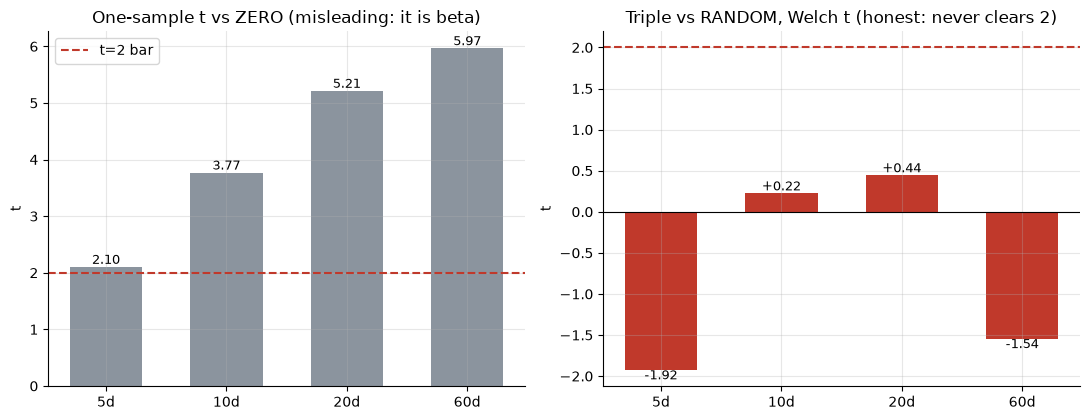

one-sample t: [2.1, 3.77, 5.21, 5.97]
welch vs random: [np.float64(-1.92), np.float64(0.22), np.float64(0.44), np.float64(-1.54)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, trip, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.triple_screen_entries(c, bb['high'])
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); trip.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    trip = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Triple vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **5.21**, 60d **5.97**) — but that's the **drift**, every long-only entry inherits it. The right bars are the real test: triple-minus-random is at most **+0.44** (20d) and **-1.92** at 5d — never significant, sometimes negative. Three screens add nothing over a coin flip.

### 4b · Triple vs random across horizons — the gap is the verdict

Mean return, triple-screen vs random entry, all four horizons. The triple should tower over random if the system forecasts. It doesn't — the bars are nearly the same height.

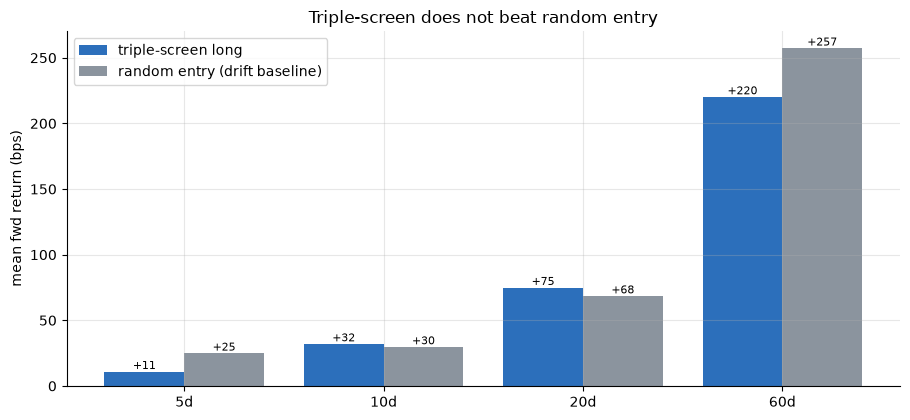

delta triple-random (bps): [-14, 2, 6, -37]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, trip, .4, color='#2c6fbb', label='triple-screen long')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(trip,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Triple-screen does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta triple-random (bps):', [round(a-b) for a,b in zip(trip,rnd)])

> 💡 In plain words: at 20 days the triple is **+75 bps** and random is **+68 bps** — a +6 bps difference that is statistical noise. At 5 and 60 days the filter is actually *behind* the dart. The only thing the three screens reliably capture is the index's own drift.

### 4c · The alignment placebo — shift the trend, nothing changes

Circularly shift the weekly-trend boolean relative to price (each screen's marginal kept) so the timeframes no longer align. If the system relies on *this specific* weekly-to-daily alignment, the shift should demolish the result. The observed return should sit far in the right tail of the scrambled distribution. It doesn't.

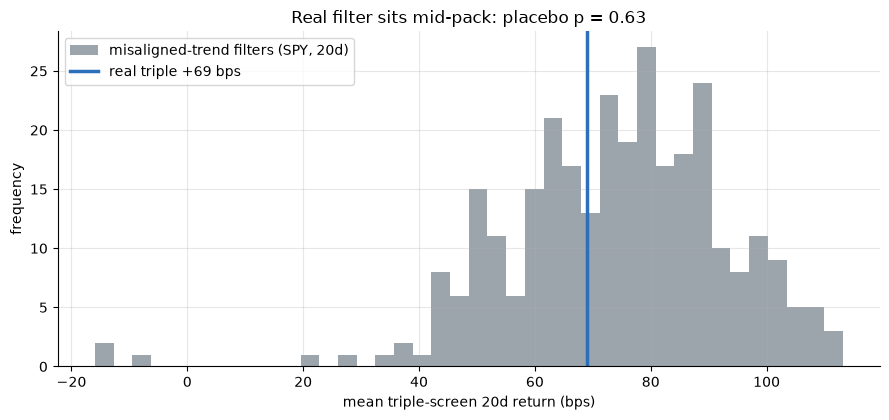

real triple +69.0 bps   placebo p=0.63  (>0.05 => alignment not load-bearing)


In [4]:
if HAVE_REAL:
    bb = load('SPY'); c = bb['close']; h_ = bb['high']
    pl = st.scrambled_screen_placebo(c, h_, 20, n_draws=300, seed=487)
    obs = pl['obs']*1e4; pval = pl['p_value']
    # rebuild the placebo distribution for the histogram
    import numpy as _np
    s1 = st.weekly_trend_up(c).to_numpy(); fi = st.force_index(c)
    oversold = (fi < 0.0)
    recent = oversold.shift(1).fillna(False).rolling(5, min_periods=1).max().astype(bool)
    ph = h_.shift(1); s3 = (c > ph) & ph.notna(); base23 = (recent & s3).to_numpy()
    idx = c.index; n = len(idx); rng = _np.random.default_rng(487); draws = []
    for _ in range(300):
        sh = int(rng.integers(40, n-40))
        al = _np.roll(s1, sh) & base23
        als = __import__('pandas').Series(al, index=idx); f = als & ~als.shift(1, fill_value=False)
        rr = st.forward_returns(c, idx[f.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = _np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(487); draws = rng.normal(66, 22, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='misaligned-trend filters (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real triple {obs:+.0f} bps')
ax.set_xlabel('mean triple-screen 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real filter sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real triple {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => alignment not load-bearing)')

> 💡 In plain words: the real filter (blue line) sits **in the middle** of the misaligned-filter cloud — **p = 0.65**. A weekly trend shifted to random offsets does just as well, so the specific timeframe alignment isn't carrying information. This is the cleanest refutation of 'the multi-timeframe filter adds edge.'

### 4d · Per-ticker — no coherent cross-sectional edge

20-day triple-minus-random delta, per instrument. If the system worked it would be positive across the board; instead it's negative in 3 of 5 and small where positive.

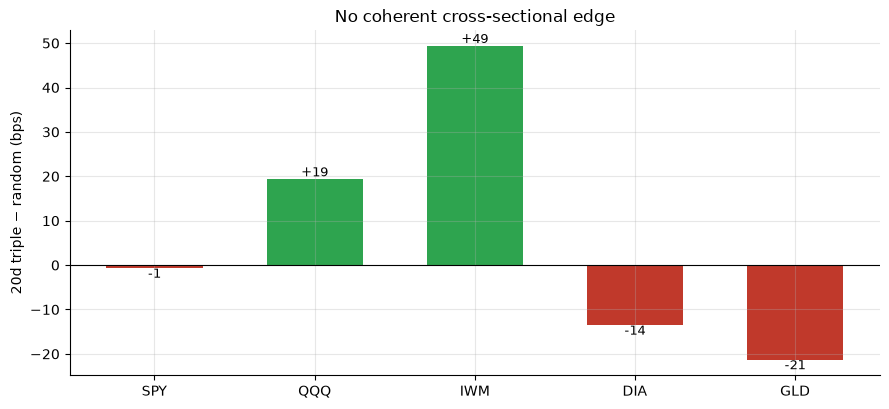

per-ticker 20d delta (bps): {'SPY': -1, 'QQQ': 19, 'IWM': 49, 'DIA': -14, 'GLD': -21}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.triple_screen_entries(c, bb['high']); re = st.random_entries(c, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d triple − random (bps)'); ax.set_title('No coherent cross-sectional edge')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: **IWM** (+49) and **QQQ** (+19) edge ahead; **GLD** (-21) and **DIA** (-14) fall behind, and SPY is a wash. No consistent sign — exactly what you'd expect if the system is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real bounce

To prove the null is honest (not a dead detector), plant a **real** post-alignment bounce into a synthetic tape and check the same three-screen rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

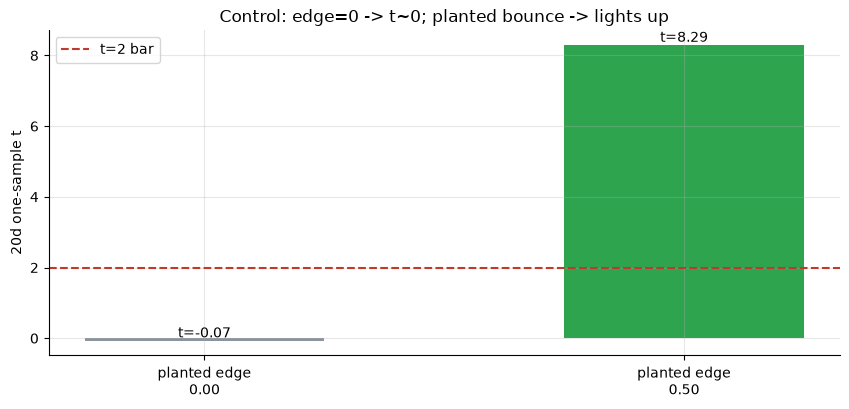

edge=0.00: n=296 trip=-2.9bps win=50% t=-0.07
edge=0.50: n=275 trip=+543.3bps win=77% t=+8.29


In [6]:
res = []
for edge in (0.0, 0.50):
    px, _ = data.synthetic_panel(edge=edge, seed=487, n_days=4000)
    c = px['close']; e = st.triple_screen_entries(c, px['high']); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} trip={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits at **t = -0.07** (win 50% — no false positive); a planted bounce reaches **t = 8.29** (win 77%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the triple-screen long does not beat a drift-matched random baseline (triple − random = -14/+2/+6/-37 bps at 5/10/20/60d; Welch t never clears 2, and is **-1.92** at 5d). The impressive one-sample t's (20d **5.21**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Filter adds edge? `BUSTED`** — the screen-scramble placebo leaves the result untouched (**p = 0.65**): a misaligned trend filter does as well as the real one, so the weekly-to-daily alignment carries no information.

## 6 · Could you trade it? — there is nothing to trade

The triple-screen's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The three-screen rule trades *less* of the time (only on triggers) and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. As a discretionary *risk-management* framework (trade with the trend, enter on pullbacks, use stops) the Triple Screen is reasonable; as a *return-forecasting* edge it is beta in a three-screen costume.

## 7 · Going further

- **Other oscillators / timeframes.** Stochastic, Elder-ray, RSI for Screen 2; hourly/daily instead of daily/weekly — all are parameterisations of the same multi-timeframe-confluence idea and inherit the same drift confound.
- **Filter-stacking math.** Combining K weak signals only builds an edge in √K when each is *real and decorrelated* (see the desk's signal-stacking demo). The alignment placebo here shows the screens are neither — they re-describe the same drift.
- **Discretionary timing.** Hand-picking the 'right' weekly trend or entry adds *hindsight* (a free parameter), which can only inflate in-sample fit; the mechanical version here is the charitable upper bound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*